# Indikator Citra Satelit Kabupaten/Kota Sulawesi Tenggara dari Google Earth Engine

Notebook ketiga ini menarik indikator bulanan dari citra satelit untuk 17 kabupaten/kota memakai batas wilayah yang sama dengan paket data. Indikator dipakai untuk tiga keperluan: pembanding kemiskinan kabupaten/kota (cahaya malam), sinyal pasokan pangan dan ikan (curah hujan, kehijauan lahan pertanian, suhu permukaan laut, klorofil-a), dan model nowcast tambahan pada notebook keempat.

Urutan kerja kita:

1. Menyiapkan lingkungan kerja dan folder keluaran.
2. Menghubungkan Google Earth Engine dengan proyek `ee-baratalade`.
3. Menyusun wilayah daratan dan perairan pesisir tiap kabupaten/kota.
4. Menarik indikator bulanan dan indikator tutupan lahan.
5. Menganalisis hubungan indikator satelit dengan kemiskinan, harga pangan, dan nilai tukar nelayan.
6. Menyimpan berkas untuk notebook keempat dan memaketkan keluaran.

Penarikan data pertama memerlukan waktu karena dilakukan per tahun untuk setiap sumber data. Hasilnya disimpan, sehingga pada run berikutnya hanya bulan yang belum ada yang ditarik ulang (atur `TARIK_ULANG = True` untuk menarik semuanya kembali).

## Langkah 1. Lingkungan kerja dan folder keluaran

In [1]:
import os, sys, re, glob, json, zipfile, shutil, textwrap, warnings, time, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from scipy.stats import spearmanr, pearsonr

warnings.filterwarnings('ignore')
try:
    import ee
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'earthengine-api', '--quiet'])
    import ee
for pola in ['fonts/*.ttf', 'fonts/*.TTF', 'C:/Windows/Fonts/times*.ttf', os.path.expanduser('~/Library/Fonts/Times*.ttf'),
             '/Library/Fonts/Times*.ttf', '/usr/share/fonts/**/[Tt]imes*.ttf', os.path.expanduser('~/.fonts/*.ttf')]:
    for berkas in glob.glob(pola, recursive=True):
        try:
            font_manager.fontManager.addfont(berkas)
        except Exception:
            pass
tersedia = {f.name for f in font_manager.fontManager.ttflist}
FONT_UTAMA = next((f for f in ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'TeX Gyre Termes', 'DejaVu Serif'] if f in tersedia), 'DejaVu Serif')
plt.rcParams.update({
    'font.family': 'serif', 'font.serif': [FONT_UTAMA, 'Times New Roman', 'DejaVu Serif'], 'font.size': 13,
    'axes.titlesize': 13, 'axes.labelsize': 13, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13,
    'figure.titlesize': 13, 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 100, 'savefig.dpi': 300})

USE_GDRIVE = False
DI_COLAB = 'google.colab' in sys.modules
if USE_GDRIVE and DI_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/Forkestra2026'
else:
    BASE_DIR = os.getcwd()
OUT_DIR = os.path.join(BASE_DIR, 'output_forkestra2026_satelit')
SUB = {k: os.path.join(OUT_DIR, k) for k in ['figures', 'tables', 'interpretations', 'cache']}
for p in SUB.values():
    os.makedirs(p, exist_ok=True)
TABEL, GAMBAR, TAFSIR = {}, {}, {}
PROJECT_ID = 'ee-baratalade'
AWAL_TAHUN = 2019
TARIK_ULANG = False

def angka(x, d=2):
    try:
        x = float(x)
    except (TypeError, ValueError):
        return 'tidak tersedia'
    return 'tidak tersedia' if not np.isfinite(x) else f'{x:,.{d}f}'.replace(',', '#').replace('.', ',').replace('#', '.')

def simpan_tabel(df, kode, judul):
    df.to_csv(os.path.join(SUB['tables'], f'{kode}.csv'), index=False, encoding='utf-8')
    TABEL[kode] = (judul, df.copy())
    return df

def simpan_gambar(fig, kode, judul):
    path = os.path.join(SUB['figures'], f'{kode}.png')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    GAMBAR[kode] = (judul, path)
    plt.show()
    plt.close(fig)

def tafsir(kode, teks):
    teks = re.sub(r'\s+', ' ', teks).strip()
    TAFSIR.setdefault(kode, []).append(teks)
    print(textwrap.fill(teks, 115))
    print()

def label_titik(ax, xs, ys, labels, fs=13):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    terpasang = []
    geser = [(6, 5), (6, -15), (-24, 5), (-24, -15), (10, 15), (-28, 15), (10, -25), (-28, -25), (16, 0), (-34, 0)]
    for x, y, lab in zip(xs, ys, labels):
        if not (np.isfinite(x) and np.isfinite(y)):
            continue
        for dx, dy in geser:
            t = ax.annotate(lab, (x, y), xytext=(dx, dy), textcoords='offset points', fontsize=fs)
            kotak = t.get_window_extent(renderer=renderer).expanded(1.08, 1.15)
            if not any(kotak.overlaps(q) for q in terpasang):
                terpasang.append(kotak)
                break
            t.remove()

print('Huruf grafik:', FONT_UTAMA, '| folder keluaran:', OUT_DIR)

Huruf grafik: Liberation Serif | folder keluaran: /content/output_forkestra2026_satelit


## Langkah 2. Menghubungkan Google Earth Engine

Pada run pertama, `ee.Authenticate()` membuka halaman masuk akun Google yang terdaftar di Earth Engine. Setelah token tersimpan, run berikutnya langsung memakai proyek `ee-baratalade`.

In [2]:
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
print('Earth Engine siap, proyek:', PROJECT_ID)

Earth Engine siap, proyek: ee-baratalade


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## Langkah 3. Wilayah daratan dan perairan pesisir

Batas 17 kabupaten/kota diambil dari berkas GeoJSON di paket data. Perairan pesisir tiap wilayah adalah penyangga 20 km dari garis batas dikurangi seluruh daratan provinsi. Zona ini dipakai untuk suhu permukaan laut dan klorofil-a, yang menjadi penanda kondisi perairan tempat nelayan setempat umumnya menangkap ikan.

In [3]:
def cari_berkas(nama):
    kandidat = [os.path.join(BASE_DIR, nama), os.path.join(BASE_DIR, 'data', nama), os.path.join(os.path.expanduser('~'), 'Downloads', nama)]
    ada = next((k for k in kandidat if os.path.exists(k)), None)
    if ada is None and DI_COLAB:
        from google.colab import files
        ada = os.path.join(os.getcwd(), next(iter(files.upload())))
    if ada is None:
        ada = input('Jalur lengkap berkas ' + nama + ': ').strip().strip('"')
    return ada

DATA_DIR = os.path.join(BASE_DIR, 'dataset_final_sultra')
if not os.path.isdir(DATA_DIR):
    with zipfile.ZipFile(cari_berkas('dataset_final_sultra_forkestra2026.zip')) as z:
        z.extractall(BASE_DIR)
with open(os.path.join(DATA_DIR, '05_spatial', 'boundaries_kabkota_sultra_simplified.geojson'), encoding='utf-8') as f:
    GEO = json.load(f)
spat = pd.read_csv(os.path.join(DATA_DIR, '05_spatial', 'spatial_regions.csv'))
NAMA = spat.set_index('region_code')['region_name'].to_dict()

def bulatkan(koord):
    return [bulatkan(c) for c in koord] if isinstance(koord[0], list) else [round(koord[0], 4), round(koord[1], 4)]

fitur = []
for ft in GEO['features']:
    kode = int(ft['properties']['region_code'])
    g = ft['geometry']
    geom = ee.Geometry.MultiPolygon(bulatkan(g['coordinates'])) if g['type'] == 'MultiPolygon' else ee.Geometry.Polygon(bulatkan(g['coordinates']))
    fitur.append(ee.Feature(geom, {'region_code': kode}))
DARAT_FC = ee.FeatureCollection(fitur)
DARAT = DARAT_FC.union(maxError=100).geometry()
LAUT_FC = DARAT_FC.map(lambda f: ee.Feature(f.geometry().buffer(20000, maxError=200).difference(DARAT, maxError=200), {'region_code': f.get('region_code')}))
WORLDCOVER = ee.ImageCollection('ESA/WorldCover/v200').first().select('Map')
LAHAN_TANI = WORLDCOVER.eq(40)
print('Jumlah wilayah:', DARAT_FC.size().getInfo())

Saving dataset_final_sultra_forkestra2026.zip to dataset_final_sultra_forkestra2026.zip
Jumlah wilayah: 17


## Langkah 4. Menarik indikator bulanan dan tutupan lahan

Sumber data dan cara ringkasnya:

| Indikator | Koleksi Earth Engine | Ringkasan bulanan | Wilayah | Skala |
|---|---|---|---|---|
| Cahaya malam (nW/cm²/sr) | `NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG`, pita `avg_rad` | komposit bulanan | daratan | 500 m |
| Curah hujan (mm) | `UCSB-CHG/CHIRPS/DAILY`, pita `precipitation` | jumlah harian | daratan | 5 km |
| NDVI lahan pertanian | `MODIS/061/MOD13Q1`, pita `NDVI` dikali 0,0001 | rata-rata, hanya piksel lahan pertanian WorldCover | daratan | 250 m |
| Suhu permukaan laut (°C) dan klorofil-a (mg/m³) | `NASA/OCEANDATA/MODIS-Aqua/L3SMI`, pita `sst` dan `chlor_a` | rata-rata harian | perairan 20 km | 4 km |

Setiap nilai adalah rata-rata spasial di dalam wilayah. Penarikan dilakukan per tahun dan per sumber, lalu disimpan di folder `cache`.

In [4]:
KOSONG = lambda nama: ee.Image.constant(0).rename(nama).updateMask(ee.Image.constant(0))

def citra_bulanan(sumber, s, e):
    if sumber == 'ntl':
        col = ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG').filterDate(s, e).select('avg_rad')
        return ee.Image(ee.Algorithms.If(col.size().gt(0), col.mean(), KOSONG('avg_rad'))).rename('ntl_mean')
    if sumber == 'rain':
        col = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').filterDate(s, e).select('precipitation')
        return ee.Image(ee.Algorithms.If(col.size().gt(0), col.sum(), KOSONG('precipitation'))).rename('rain_mm')
    if sumber == 'ndvi':
        col = ee.ImageCollection('MODIS/061/MOD13Q1').filterDate(s, e).select('NDVI')
        return ee.Image(ee.Algorithms.If(col.size().gt(0), col.mean(), KOSONG('NDVI'))).multiply(0.0001).updateMask(LAHAN_TANI).rename('ndvi_crop')
    col = ee.ImageCollection('NASA/OCEANDATA/MODIS-Aqua/L3SMI').filterDate(s, e).select(['sst', 'chlor_a'])
    kosong = KOSONG('sst').addBands(KOSONG('chlor_a'))
    return ee.Image(ee.Algorithms.If(col.size().gt(0), col.mean(), kosong)).rename(['sst_c', 'chl_mg_m3'])

SUMBER = {'ntl': (DARAT_FC, 500, ['ntl_mean']), 'rain': (DARAT_FC, 5000, ['rain_mm']), 'ndvi': (DARAT_FC, 250, ['ndvi_crop']),
          'ocean': (LAUT_FC, 4000, ['sst_c', 'chl_mg_m3'])}

def tarik_tahun(sumber, tahun, bulan=tuple(range(12))):
    fc, skala, pita = SUMBER[sumber]
    awal = ee.Date.fromYMD(tahun, 1, 1)
    def per_bulan(m):
        s = awal.advance(ee.Number(m), 'month')
        img = citra_bulanan(sumber, s, s.advance(1, 'month'))
        red = ee.Reducer.mean() if len(pita) > 1 else ee.Reducer.mean().setOutputs(pita)
        hasil = img.reduceRegions(collection=fc, reducer=red, scale=skala, tileScale=4)
        return hasil.map(lambda f: ee.Feature(None, f.toDictionary().set('period', s.format('YYYY-MM'))))
    data = ee.FeatureCollection(ee.List(list(bulan)).map(per_bulan)).flatten().getInfo()
    baris = [ft['properties'] for ft in data['features']]
    df = pd.DataFrame(baris)
    for p in pita:
        if p not in df.columns:
            df[p] = np.nan
    return df[['region_code', 'period'] + pita]

bulan_akhir = (pd.Timestamp.today().to_period('M') - 1)
semua = {}
for sumber in SUMBER:
    potongan = []
    for tahun in range(AWAL_TAHUN, bulan_akhir.year + 1):
        cache = os.path.join(SUB['cache'], f'{sumber}_{tahun}.csv')
        tahun_lengkap = tahun < bulan_akhir.year
        if os.path.exists(cache) and not TARIK_ULANG and tahun_lengkap:
            potongan.append(pd.read_csv(cache))
            continue
        berhasil = False
        for coba in range(3):
            try:
                t0 = time.time()
                df = tarik_tahun(sumber, tahun)
                df.to_csv(cache, index=False)
                potongan.append(df)
                print(f'{sumber} {tahun}: {len(df)} baris ({time.time() - t0:.0f} detik)')
                berhasil = True
                break
            except Exception as e:
                print(f'{sumber} {tahun}: percobaan {coba + 1} gagal ({str(e)[:120]})')
                time.sleep(10)
        if not berhasil:
            print(f'{sumber} {tahun}: beralih ke penarikan per bulan')
            per_bln = []
            for b in range(12):
                try:
                    per_bln.append(tarik_tahun(sumber, tahun, (b,)))
                except Exception as e:
                    print(f'  bulan {b + 1}: gagal ({str(e)[:80]})')
            if per_bln:
                df = pd.concat(per_bln, ignore_index=True)
                df.to_csv(cache, index=False)
                potongan.append(df)
    semua[sumber] = pd.concat(potongan, ignore_index=True) if potongan else pd.DataFrame(columns=['region_code', 'period'] + SUMBER[sumber][2])
SAT = None
for sumber, df in semua.items():
    SAT = df if SAT is None else SAT.merge(df, on=['region_code', 'period'], how='outer')
SAT['region_code'] = SAT['region_code'].astype(int)
SAT = SAT[SAT['period'] <= str(bulan_akhir)].sort_values(['region_code', 'period']).reset_index(drop=True)
SAT.insert(1, 'region_name', SAT['region_code'].map(NAMA))

lc = WORLDCOVER
luas = ee.Image.pixelArea().divide(1e6)
statis = luas.updateMask(lc.eq(95)).rename('mangrove_km2').addBands(luas.updateMask(lc.eq(40)).rename('cropland_km2')).addBands(luas.updateMask(lc.eq(50)).rename('builtup_km2'))
st = statis.reduceRegions(collection=DARAT_FC, reducer=ee.Reducer.sum(), scale=100, tileScale=8).getInfo()
STATIS = pd.DataFrame([f['properties'] for f in st['features']])
STATIS['region_code'] = STATIS['region_code'].astype(int)
STATIS.insert(1, 'region_name', STATIS['region_code'].map(NAMA))

SAT.to_csv(os.path.join(SUB['tables'], 'satellite_indicators_kabkota_monthly.csv'), index=False)
SAT.to_csv(os.path.join(BASE_DIR, 'satellite_indicators_kabkota_monthly.csv'), index=False)
simpan_tabel(STATIS.round(3), 'G01_land_cover_static', 'Mangrove, cropland, and built-up area by regency/city (ESA WorldCover 2021)')
cakupan = SAT.groupby('period')[['ntl_mean', 'rain_mm', 'ndvi_crop', 'sst_c', 'chl_mg_m3']].count()
print('Periode:', SAT['period'].min(), 'sampai', SAT['period'].max(), '| baris:', len(SAT))
display(cakupan.tail(6))

ntl 2019: 204 baris (2 detik)
ntl 2020: 204 baris (2 detik)
ntl 2021: 204 baris (2 detik)
ntl 2022: 204 baris (2 detik)
ntl 2023: 204 baris (2 detik)
ntl 2024: 204 baris (2 detik)
ntl 2025: 204 baris (2 detik)
ntl 2026: 204 baris (2 detik)
rain 2019: 204 baris (2 detik)
rain 2020: 204 baris (2 detik)
rain 2021: 204 baris (2 detik)
rain 2022: 204 baris (2 detik)
rain 2023: 204 baris (2 detik)
rain 2024: 204 baris (2 detik)
rain 2025: 204 baris (2 detik)
rain 2026: 204 baris (2 detik)
ndvi 2019: 204 baris (3 detik)
ndvi 2020: 204 baris (2 detik)
ndvi 2021: 204 baris (2 detik)
ndvi 2022: 204 baris (2 detik)
ndvi 2023: 204 baris (2 detik)
ndvi 2024: 204 baris (3 detik)
ndvi 2025: 204 baris (2 detik)
ndvi 2026: 204 baris (2 detik)
ocean 2019: 204 baris (34 detik)
ocean 2020: 204 baris (26 detik)
ocean 2021: 204 baris (41 detik)
ocean 2022: 204 baris (32 detik)
ocean 2023: 204 baris (37 detik)
ocean 2024: 204 baris (41 detik)
ocean 2025: 204 baris (27 detik)
ocean 2026: 204 baris (32 detik)


,ntl_mean,rain_mm,ndvi_crop,sst_c,chl_mg_m3
period,,,,,
2026-03,17,17,15,0,0
2026-04,17,17,15,0,0
2026-05,17,17,15,0,0
2026-06,17,17,15,0,0
2026-07,17,17,15,0,0
2026-08,0,17,15,0,0


## Langkah 5. Hubungan indikator satelit dengan kemiskinan, harga pangan, dan nilai tukar nelayan

Kita melakukan empat pemeriksaan:

1. **Seri provinsi.** Rata-rata 17 wilayah per bulan beserta anomalinya terhadap rata-rata bulan kalender yang sama.
2. **Cahaya malam dan kemiskinan.** Rata-rata cahaya malam 2025 per kabupaten/kota dibandingkan dengan persentase penduduk miskin 2025 memakai korelasi peringkat Spearman.
3. **Kondisi perairan dan nelayan.** Anomali suhu permukaan laut dan klorofil-a dikorelasikan dengan perubahan bulanan harga yang diterima nelayan tangkap, dengan jeda 0 sampai 3 bulan.
4. **Curah hujan dan harga pangan.** Anomali curah hujan dikorelasikan dengan perubahan bulanan harga beras dan cabai rawit PIHPS, dengan jeda yang sama.

Korelasi ini bersifat deskriptif. Tabel mencantumkan nilai p dan jumlah bulan, dan hanya hubungan dengan nilai p di bawah 0,05 yang disebut bermakna dalam interpretasi.

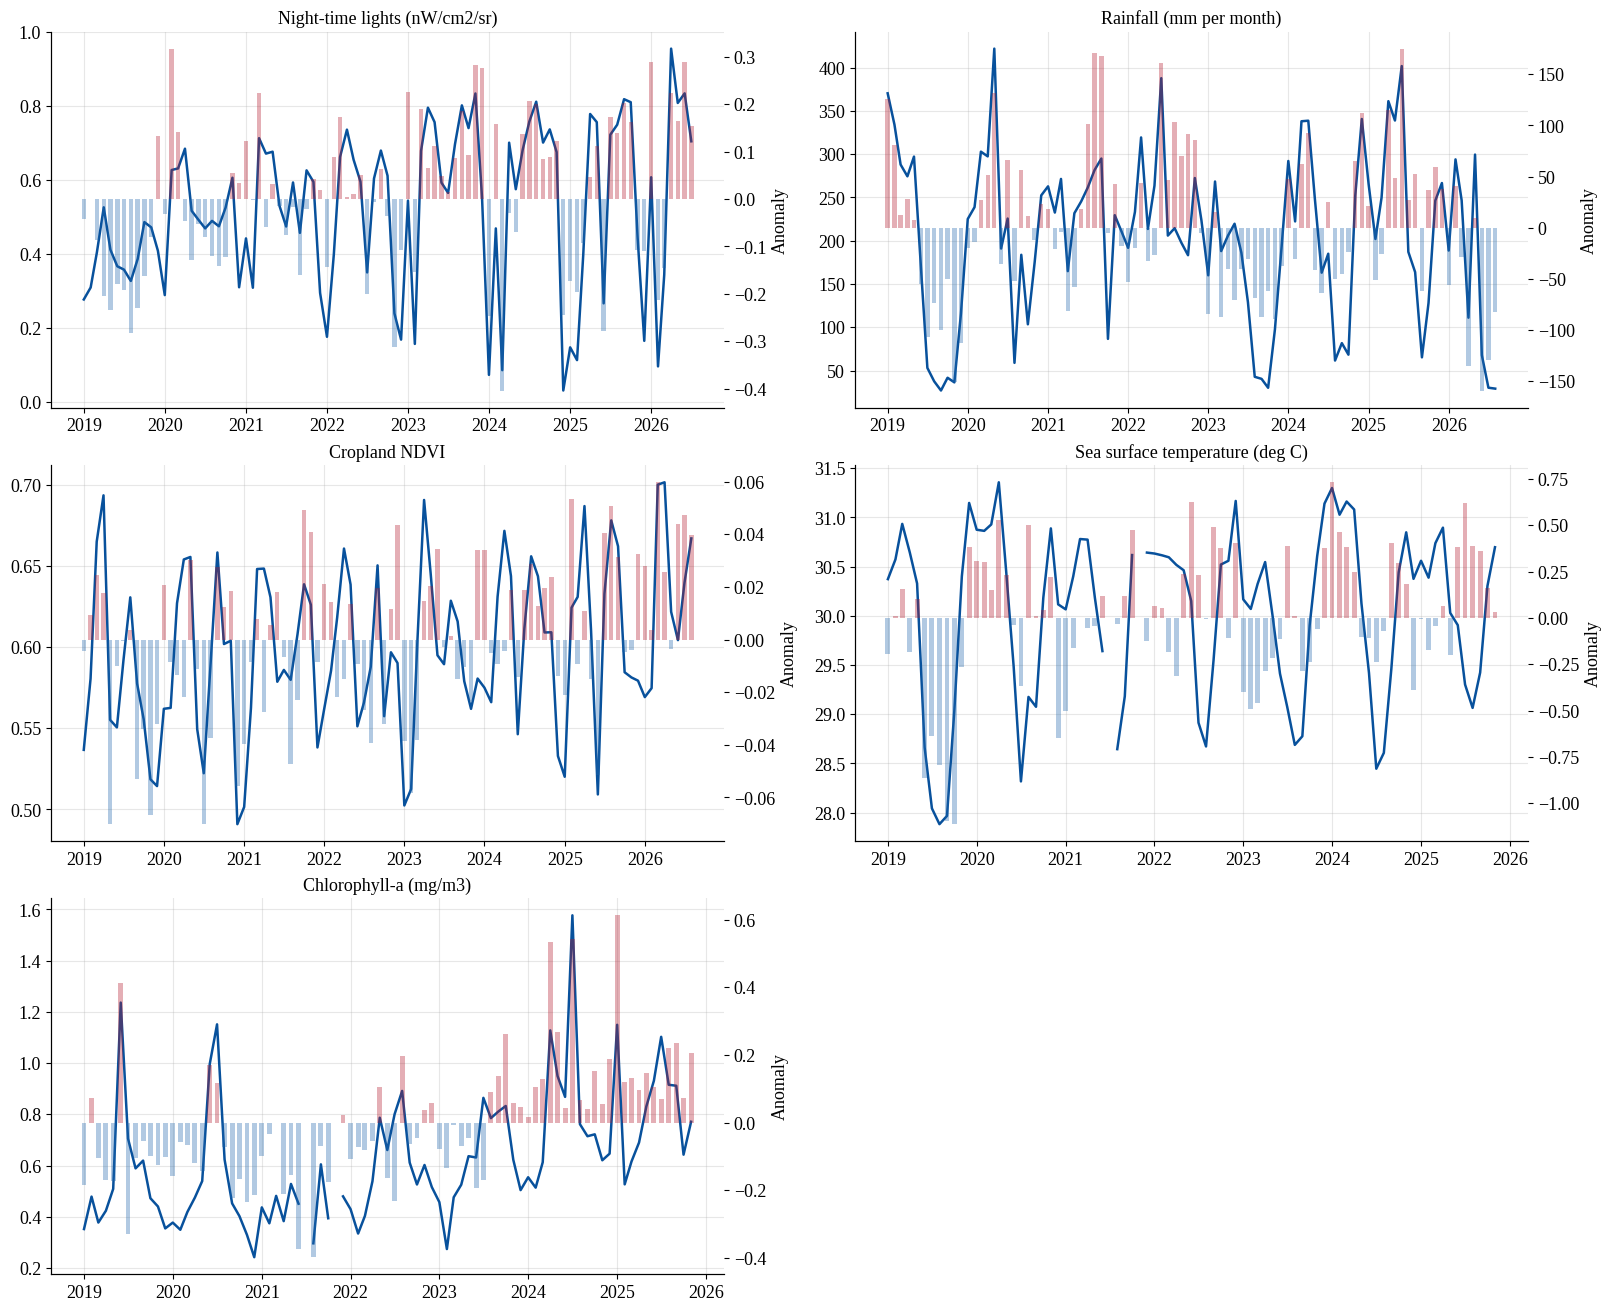

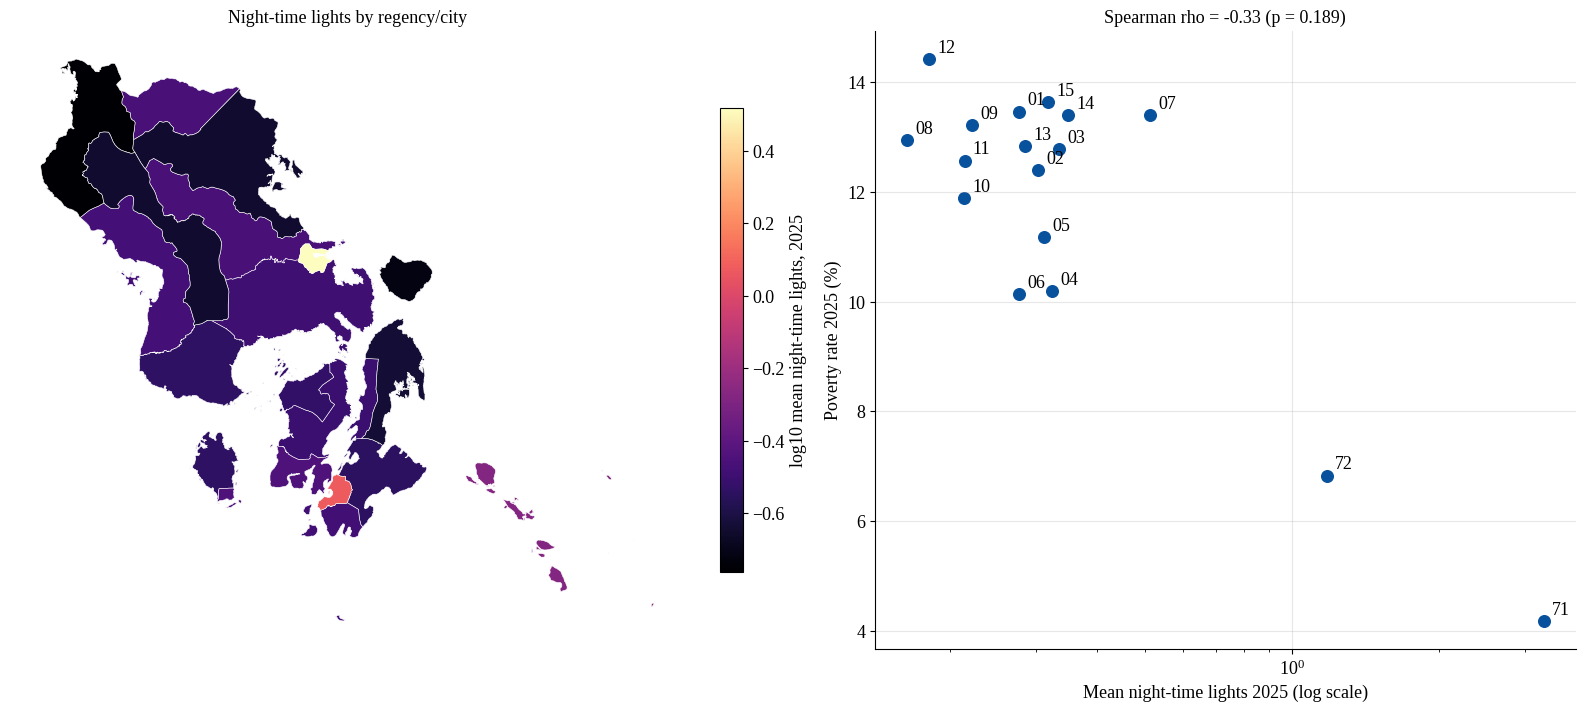

Korelasi peringkat Spearman antara cahaya malam rata-rata 2025 dan persentase penduduk miskin 2025 di 17
kabupaten/kota adalah -0,33 (nilai p 0,189). Hubungan ini belum bermakna pada taraf 5 persen, sehingga cahaya malam
belum cukup kuat dipakai sendiri sebagai penanda kemiskinan wilayah. Wilayah paling terang adalah Kota Kendari dan
paling redup Kolaka Utara.



,Satellite anomaly,"Outcome (monthly log change, %)",Lag (months),Pearson r,p-value,Months
0,Sea surface temperature,Prices received by capture fishers,0,-0.054,0.633,80
1,Sea surface temperature,Prices received by capture fishers,1,0.111,0.325,81
2,Sea surface temperature,Prices received by capture fishers,2,0.081,0.473,81
3,Sea surface temperature,Prices received by capture fishers,3,0.148,0.187,81
4,Chlorophyll-a,Prices received by capture fishers,0,0.134,0.236,80
5,Chlorophyll-a,Prices received by capture fishers,1,-0.046,0.681,81
6,Chlorophyll-a,Prices received by capture fishers,2,-0.016,0.887,81
7,Chlorophyll-a,Prices received by capture fishers,3,-0.000,0.999,81
8,Rainfall,PIHPS price: Beras,0,-0.038,0.739,78
9,Rainfall,PIHPS price: Beras,1,-0.156,0.172,78


Dari 16 pasangan jeda yang diuji, 1 bermakna pada taraf 5 persen: anomali rainfall terhadap pihps price: cabai
rawit dengan jeda 0 bulan (r -0,26, p 0,020, 78 bulan).



In [5]:
VAR = {'ntl_mean': 'Night-time lights (nW/cm2/sr)', 'rain_mm': 'Rainfall (mm per month)', 'ndvi_crop': 'Cropland NDVI',
       'sst_c': 'Sea surface temperature (deg C)', 'chl_mg_m3': 'Chlorophyll-a (mg/m3)'}
prov = SAT.groupby('period')[list(VAR)].mean()
anom = prov - prov.groupby(prov.index.str[5:7]).transform('mean')
t = pd.PeriodIndex(prov.index, freq='M').to_timestamp()
fig, axs = plt.subplots(3, 2, figsize=(16, 13), constrained_layout=True)
for ax, (k, lab) in zip(axs.flat, VAR.items()):
    ax.plot(t, prov[k], color='#08519c', lw=1.8, label='Monthly value')
    ax2 = ax.twinx()
    ax2.bar(t, anom[k], width=20, color=np.where(anom[k] > 0, '#b2182b', '#2166ac'), alpha=0.35, label='Anomaly')
    ax2.set_ylabel('Anomaly')
    ax2.grid(False)
    ax.set_title(lab)
axs.flat[-1].axis('off')
simpan_gambar(fig, 'G01_provincial_series', 'Provincial monthly satellite indicators and anomalies')

pk = pd.read_csv(os.path.join(DATA_DIR, '04_regional_socioeconomic', 'poverty_kabkota_annual.csv'))
thn = int(pk.loc[pk['variable'] == 'poverty_rate_p0', 'year'].max())
p0 = pk[(pk['variable'] == 'poverty_rate_p0') & (pk['year'] == thn)].set_index('region_code')['value']
ntl_th = SAT[SAT['period'].str.startswith(str(thn))].groupby('region_code')['ntl_mean'].mean()
G02 = pd.DataFrame({'Code': ntl_th.index.astype(str).str[2:], 'Regency/city': ntl_th.index.map(NAMA), f'Mean night-time lights {thn}': ntl_th.values,
                    f'Poverty rate {thn} (%)': ntl_th.index.map(p0).values})
G02 = G02.merge(STATIS[['region_name', 'mangrove_km2', 'cropland_km2', 'builtup_km2']].rename(columns={'region_name': 'Regency/city'}), on='Regency/city', how='left')
simpan_tabel(G02.round(4), 'G02_lights_and_poverty', f'Night-time lights and poverty by regency/city, {thn}')
ok = G02[[f'Mean night-time lights {thn}', f'Poverty rate {thn} (%)']].dropna()
rho, prho = spearmanr(np.log(ok.iloc[:, 0] + 0.01), ok.iloc[:, 1]) if len(ok) > 4 else (np.nan, np.nan)

fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
patches, vals = [], []
for ft in GEO['features']:
    kode = int(ft['properties']['region_code'])
    g = ft['geometry']
    for poly in (g['coordinates'] if g['type'] == 'MultiPolygon' else [g['coordinates']]):
        patches.append(MplPolygon(np.array(poly[0]), closed=True))
        vals.append(np.log10(ntl_th.get(kode, np.nan) + 0.01))
pc = PatchCollection(patches, cmap='magma', edgecolor='white', linewidth=0.4)
pc.set_array(np.ma.masked_invalid(np.array(vals)))
axs[0].add_collection(pc); axs[0].autoscale_view(); axs[0].set_aspect('equal'); axs[0].set_axis_off()
cb = plt.colorbar(pc, ax=axs[0], shrink=0.75)
cb.set_label(f'log10 mean night-time lights, {thn}')
axs[0].set_title('Night-time lights by regency/city')
axs[1].scatter(G02[f'Mean night-time lights {thn}'], G02[f'Poverty rate {thn} (%)'], s=70, color='#08519c')
axs[1].set_xscale('log')
axs[1].set_xlabel(f'Mean night-time lights {thn} (log scale)')
axs[1].set_ylabel(f'Poverty rate {thn} (%)')
axs[1].set_title(f'Spearman rho = {rho:.2f} (p = {prho:.3f})')
label_titik(axs[1], G02[f'Mean night-time lights {thn}'].to_numpy(), G02[f'Poverty rate {thn} (%)'].to_numpy(), G02['Code'].to_numpy())
simpan_gambar(fig, 'G02_lights_and_poverty', 'Night-time lights and poverty by regency/city')
tafsir('G02', f"Korelasi peringkat Spearman antara cahaya malam rata-rata {thn} dan persentase penduduk miskin {thn} di 17 kabupaten/kota adalah {angka(rho, 2)} "
       f"(nilai p {angka(prho, 3)}). {'Hubungan ini bermakna pada taraf 5 persen, sehingga cahaya malam dapat dipakai sebagai pembanding bulanan kondisi ekonomi wilayah di antara dua rilis kemiskinan.' if prho < 0.05 else 'Hubungan ini belum bermakna pada taraf 5 persen, sehingga cahaya malam belum cukup kuat dipakai sendiri sebagai penanda kemiskinan wilayah.'} "
       f"Wilayah paling terang adalah {G02.sort_values(f'Mean night-time lights {thn}').iloc[-1]['Regency/city']} dan paling redup {G02.sort_values(f'Mean night-time lights {thn}').iloc[0]['Regency/city']}.")

ib = pd.read_csv(os.path.join(DATA_DIR, '01_prices_inflation', 'farmer_price_indices_sultra_monthly.csv'))
it_n = ib[ib['subsector'] == 'capture_fishers'].set_index('period')['it'].sort_index()
d_it = 100 * np.log(it_n).diff()
ph = pd.read_csv(os.path.join(DATA_DIR, '01_prices_inflation', 'price_pihps_monthly.csv'))
ph = ph[ph['is_aggregate'].astype(bool)]
harga = ph.groupby(['commodity_group', 'period'])['price_filled'].mean().unstack(0).sort_index()
d_harga = 100 * np.log(harga).diff()

def korelasi_jeda(x, y, nama_x, nama_y):
    baris = []
    for jeda in range(4):
        xs = x.copy()
        xs.index = [str(pd.Period(p, freq='M') + jeda) for p in xs.index]
        z = pd.concat([xs.rename('x'), y.rename('y')], axis=1).dropna()
        r, p = pearsonr(z['x'], z['y']) if len(z) > 12 else (np.nan, np.nan)
        baris.append({'Satellite anomaly': nama_x, 'Outcome (monthly log change, %)': nama_y, 'Lag (months)': jeda, 'Pearson r': r, 'p-value': p, 'Months': len(z)})
    return baris

rows = korelasi_jeda(anom['sst_c'], d_it, 'Sea surface temperature', 'Prices received by capture fishers')
rows += korelasi_jeda(anom['chl_mg_m3'], d_it, 'Chlorophyll-a', 'Prices received by capture fishers')
for g in [c for c in ['Beras', 'Cabai Rawit'] if c in d_harga.columns]:
    rows += korelasi_jeda(anom['rain_mm'], d_harga[g], 'Rainfall', 'PIHPS price: ' + g)
G03 = pd.DataFrame(rows)
simpan_tabel(G03.round(4), 'G03_lagged_correlations', 'Lagged correlations between satellite anomalies and prices')
display(G03.round(3))
sig = G03[G03['p-value'] < 0.05]
tafsir('G03', (f"Dari {len(G03)} pasangan jeda yang diuji, {len(sig)} bermakna pada taraf 5 persen: "
               + '; '.join(f"anomali {r_['Satellite anomaly'].lower()} terhadap {r_['Outcome (monthly log change, %)'].lower()} dengan jeda {int(r_['Lag (months)'])} bulan (r {angka(r_['Pearson r'], 2)}, p {angka(r_['p-value'], 3)}, {int(r_['Months'])} bulan)" for _, r_ in sig.iterrows())
               + '.') if len(sig) else f"Dari {len(G03)} pasangan jeda yang diuji, tidak ada yang bermakna pada taraf 5 persen. Indikator satelit tetap disimpan dan diuji sebagai model nowcast tambahan pada notebook keempat, yang akan menilai kontribusinya dari galat ramalan.")

## Langkah 6. Menyimpan berkas untuk notebook keempat dan memaketkan keluaran

Berkas `satellite_indicators_kabkota_monthly.csv` disalin ke folder kerja utama. Notebook keempat akan menemukannya otomatis dan menambahkan model nowcast S, lalu membandingkan galatnya dengan model lain.

In [6]:
with pd.ExcelWriter(os.path.join(OUT_DIR, 'tables_satelit.xlsx')) as xw:
    pd.DataFrame([{'Sheet': k, 'Title': v[0]} for k, v in TABEL.items()]).to_excel(xw, sheet_name='INDEX', index=False)
    for k, (judul, df_) in TABEL.items():
        df_.to_excel(xw, sheet_name=k[:31], index=False)
    SAT.to_excel(xw, sheet_name='monthly_indicators', index=False)
with open(os.path.join(SUB['interpretations'], 'interpretasi_otomatis_satelit.md'), 'w', encoding='utf-8') as f:
    f.write('# Interpretasi otomatis: indikator citra satelit\n\n')
    for k, daftar in TAFSIR.items():
        f.write(f'## {k}\n\n' + '\n\n'.join(daftar) + '\n\n')
zip_path = shutil.make_archive(os.path.join(BASE_DIR, 'output_forkestra2026_satelit'), 'zip', OUT_DIR)
print('Tabel:', len(TABEL), '| Gambar:', len(GAMBAR), '| Berkas ZIP:', zip_path)
if DI_COLAB:
    from google.colab import files
    files.download(zip_path)
else:
    from IPython.display import FileLink, display
    display(FileLink(os.path.relpath(zip_path)))

Tabel: 3 | Gambar: 2 | Berkas ZIP: /content/output_forkestra2026_satelit.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Daftar pustaka

Didan, K. (2021). *MODIS/Terra vegetation indices 16-day L3 global 250m SIN grid V061* [Data set]. NASA EOSDIS Land Processes Distributed Active Archive Center. https://doi.org/10.5067/MODIS/MOD13Q1.061

Elvidge, C. D., Baugh, K., Zhizhin, M., Hsu, F. C., & Ghosh, T. (2017). VIIRS night-time lights. *International Journal of Remote Sensing, 38*(21), 5860-5879. https://doi.org/10.1080/01431161.2017.1342050

Funk, C., Peterson, P., Landsfeld, M., Pedreros, D., Verdin, J., Shukla, S., Husak, G., Rowland, J., Harrison, L., Hoell, A., & Michaelsen, J. (2015). The climate hazards infrared precipitation with stations: A new environmental record for monitoring extremes. *Scientific Data, 2*, 150066. https://doi.org/10.1038/sdata.2015.66

Gorelick, N., Hancher, M., Dixon, M., Ilyushchenko, S., Thau, D., & Moore, R. (2017). Google Earth Engine: Planetary-scale geospatial analysis for everyone. *Remote Sensing of Environment, 202*, 18-27. https://doi.org/10.1016/j.rse.2017.06.031

Jean, N., Burke, M., Xie, M., Davis, W. M., Lobell, D. B., & Ermon, S. (2016). Combining satellite imagery and machine learning to predict poverty. *Science, 353*(6301), 790-794. https://doi.org/10.1126/science.aaf7894

NASA Ocean Biology Processing Group. (2022). *MODIS-Aqua level-3 standard mapped image ocean color and sea surface temperature data* [Data set]. NASA Ocean Biology Distributed Active Archive Center. https://oceancolor.gsfc.nasa.gov

Zanaga, D., Van De Kerchove, R., Daems, D., De Keersmaecker, W., Brockmann, C., Kirches, G., Wevers, J., Cartus, O., Santoro, M., Fritz, S., Lesiv, M., Herold, M., Tsendbazar, N. E., Xu, P., Ramoino, F., & Arino, O. (2022). *ESA WorldCover 10 m 2021 v200* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.7254221